In [184]:
import pandas as pd
import numpy as np

In [185]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [186]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


car fuel efficiency distribution

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

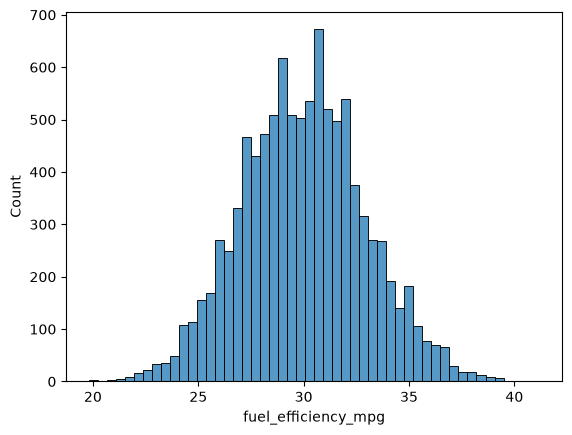

In [188]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [189]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [190]:
df.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

### Prepare and split the dataset

In [191]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

### Resetting the index

In [192]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

### Preparing y and removing fuel_efficiency_mpg

In [193]:
y_train = np.array(df_train.fuel_efficiency_mpg)
y_val = np.array(df_val.fuel_efficiency_mpg)
y_test = np.array(df_test.fuel_efficiency_mpg)

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

## Training a linear regression model

In [194]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

## Selecting the base  && Dealing with missing values

In [211]:
base = ['engine_displacement','horsepower','vehicle_weight','model_year']

X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

## Comparing the predictions with the actual fuel efficiency

<Axes: ylabel='Count'>

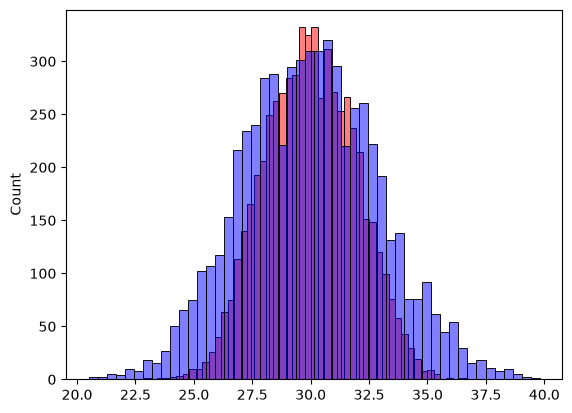

In [196]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

### RMSE

In [197]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [198]:
rmse(y_train, y_pred)

np.float64(2.2001846833713965)

In [199]:
df_val.describe()

,model_year,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration
count,2000.00000,2000.000000,2000.000000,2000.000000,1824.000000,2000.000000,1944.000000
mean,1999.53300,3.512500,2270.205000,6.025000,254.382127,4290.575000,18.922428
std,14.07718,0.958803,186.238155,0.548202,23.312171,268.505991,1.274470
min,1975.00000,2.000000,1700.000000,4.000000,181.000000,3370.000000,14.400000
25%,1987.75000,3.000000,2150.000000,6.000000,238.000000,4110.000000,18.100000
50%,2000.00000,4.000000,2270.000000,6.000000,254.000000,4290.000000,18.900000
75%,2011.00000,4.000000,2400.000000,6.000000,270.000000,4470.000000,19.700000
max,2024.00000,5.000000,2900.000000,7.000000,332.000000,5200.000000,23.200000


### Computing RMSE on validation data Option 1

In [217]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [212]:
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(2.20529319475341)

### Option 2 - replace missing values with mean value

In [215]:
base = ['engine_displacement','horsepower','vehicle_weight','model_year']

X_train2 = df_train[base].fillna(df_train[base].mean()).values

w0, w = train_linear_regression(X_train2, y_train)

y_pred2 = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

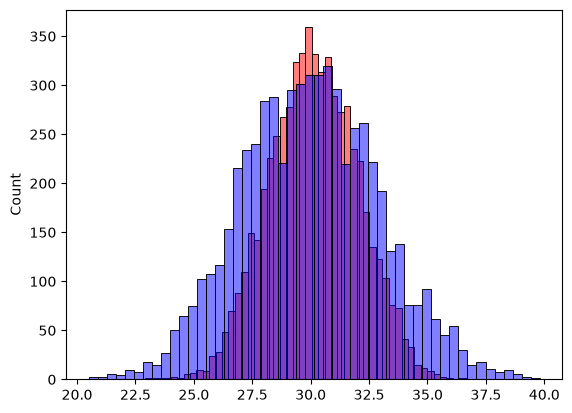

In [214]:
sns.histplot(y_pred2, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [206]:
rmse(y_train, y_pred2)

np.float64(2.2571736379340672)

### Computing RMSE on validation data Option 2

In [207]:
def prepare_X2(df):
    df_num = df[base]
    df_num = df_num.fillna(df_num.mean())
    X = df_num.values
    return X

In [216]:
X_val2 = prepare_X2(df_val)
y_pred2 = w0 + X_val2.dot(w)
rmse(y_val, y_pred2)

np.float64(2.2018099164429406)

### Regularization

In [220]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [222]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score)


0 -153.8849618823138 2.20529319475341
0.01 -148.3092124404723 2.2058276166720066
0.1 -111.83871039306318 2.2241432777850454
1 -32.331865964971264 2.3492288883928363
5 -7.7728522099734025 2.40938016659955
10 -3.9871164160193766 2.419469865473249
100 -0.40821964884790385 2.429202138016282


### Q5

In [225]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    X_train = prepare_X(df_train)
    y_train = np.array(df_train.fuel_efficiency_mpg)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val)
    y_val = np.array(df_val.fuel_efficiency_mpg)                                
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    scores.append(score)

print(scores)
print(round(np.std(scores),3))
    


[np.float64(2.239204143046126), np.float64(2.2021128210838845), np.float64(2.1634197787530947), np.float64(2.2043588768539224), np.float64(2.2018800943311554), np.float64(2.2457851509085134), np.float64(2.2697212079524043), np.float64(2.190794599933443), np.float64(2.216611201686444), np.float64(2.2070365928178957)]
0.029


### Q6

In [228]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_full_train=pd.concat([df_train, df_val])

y_train = np.array(df_train.fuel_efficiency_mpg)
y_val = np.array(df_val.fuel_efficiency_mpg)
y_test = np.array(df_test.fuel_efficiency_mpg)

X_full_train=prepare_X(df_full_train)
y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score


np.float64(2.235827747191731)